## Problem Statement

Imagine we work for a **medical insurance company** that wants to better understand its customers to improve its services. To achieve this, the company has compiled a dataset containing key information about its clients. By analyzing features such as age, BMI, and region, we can uncover trends and patterns that can inform decisions about insurance plans, marketing strategies, and risk assessment.

Our goal is to explore various predictive tasks using this dataset to gain deeper insights into the customers. These tasks include:

1. **Classification Task 1**: Predicting the gender of an individual based on other features.  
2. **Classification Task 2**: Determining whether an individual is a smoker based on other features.  
3. **Regression Task**: Estimating the insurance cost for an individual using other features.

To accomplish these tasks, we will use the **Perceptron algorithm**, one of the simplest and most foundational types of neural networks. Despite its simplicity, the Perceptron introduces essential concepts in machine learning and classification, making it a great starting point for understanding how models learn from data.

### About the Dataset

The dataset includes the following features for each individual:  
- **Age**: The age of the individual.  
- **Sex**: The gender of the individual (male or female).  
- **BMI**: Body Mass Index, a measure of body fat based on height and weight.  
- **Children**: Number of children covered by the insurance plan.  
- **Smoker**: Whether the individual is a smoker (yes or no).  
- **Region**: The individual's region of residence (e.g., northeast, southeast, etc.).  
- **Charges**: The medical insurance cost for the individual.

By the end of this notebook, you will understand how to use the Perceptron algorithm to perform both classification and regression tasks, providing a foundational understanding of machine learning.  

Let's dive in!


## Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import torch
import torch.nn as nn
import torch.optim as optim

## Data Gathering

In [2]:


df = pd.read_csv("./medical_insurance.csv")


In [3]:
df.head() # This displays the 5 rows of the dataset by default

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Exploratory Data Analysis (EDA)

### Check the size of the dataset

In [4]:
size = df.shape
print(f"The dataset has {size[0]} rows and {size[1]} columns")

The dataset has 2772 rows and 7 columns


### Check if NULL/Empty cells are present in the dataset

It checks every column for null values in the dataset and returns the count of all the null values in each column

In [5]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Check the datatypes of each column in the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


### Explore the statistics of the numerical columns in the dataset
This cell provides a summary of statistics (count, mean, std, min, 25%, 50%, 75%, and max) for numerical columns in a DataFrame.

In [7]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


### Explore the statistics of the categorical columns in the dataset

In [8]:
df.describe(include='object')

,sex,smoker,region
count,2772,2772,2772
unique,2,2,4
top,male,no,southeast
freq,1406,2208,766


### Check if there are duplicates in the dataset

In [9]:
df.duplicated()

print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 1435


### Drop the duplicates

In [10]:
print(f'before: {df.duplicated().sum()}')
df.drop_duplicates(inplace = True, ignore_index = True)
print(f'after: {df.duplicated().sum()}')

before: 1435
after: 0


### Explore the class distribution in all the categorical columns

In [11]:
categorical_columns = ['sex', 'smoker', 'region']

for column in categorical_columns:
    print(f"Class distribution for {column}:")
    print(df[column].value_counts())
    print()

Class distribution for sex:
sex
male      675
female    662
Name: count, dtype: int64

Class distribution for smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

Class distribution for region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64



### Understand the dataset through visualizations

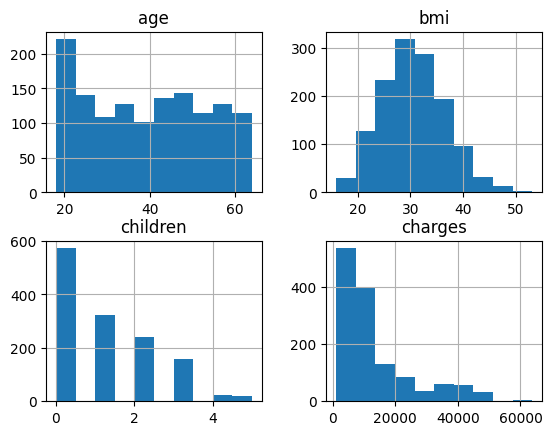

In [12]:
df.hist()
plt.show()

From the above visulaizations, we can see the following :
1. Majority of people are adults, have a relatively healthy BMI, and have no or few children.
2. Medical charges vary widely, with a significant number of people facing high costs.

In [13]:
number_column = df.select_dtypes(include=['int64' , 'float64'])
object_column = df.select_dtypes(include='object')

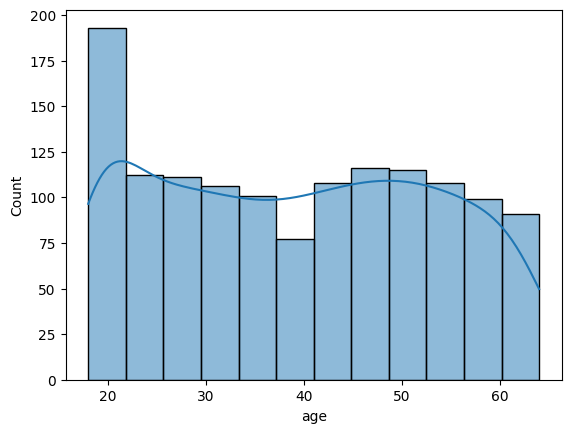

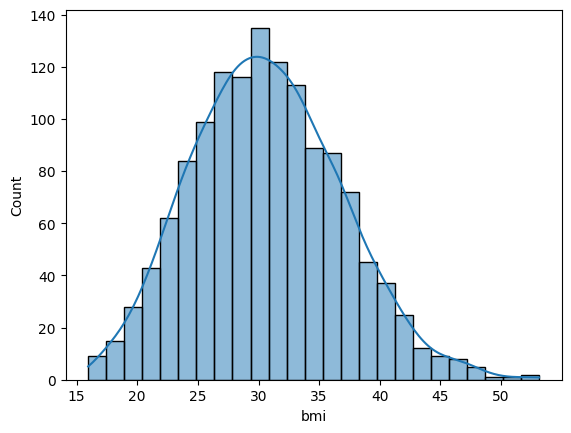

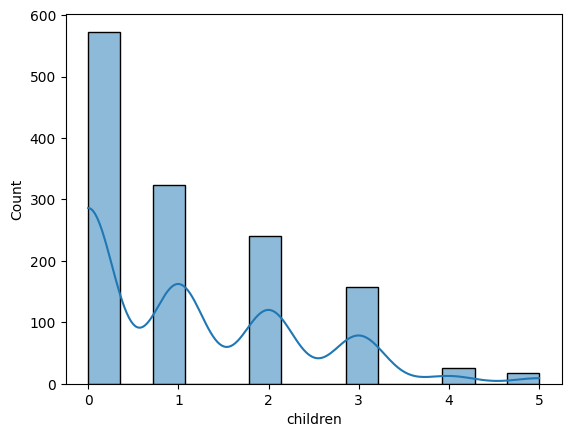

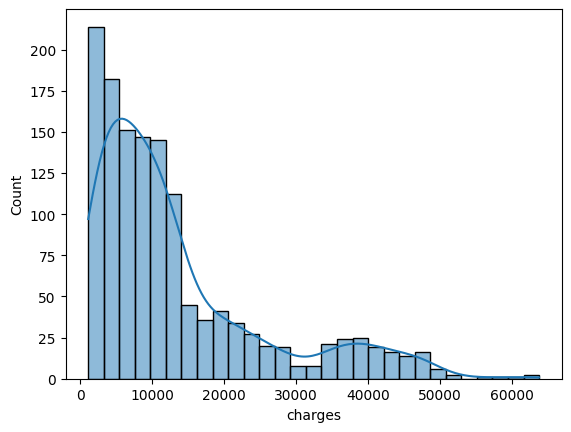

In [14]:
for column in number_column:
    sns.histplot(data = df , x = column , kde = True)
    plt.show()

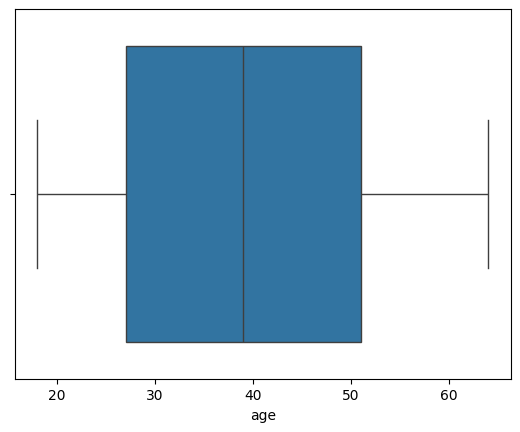

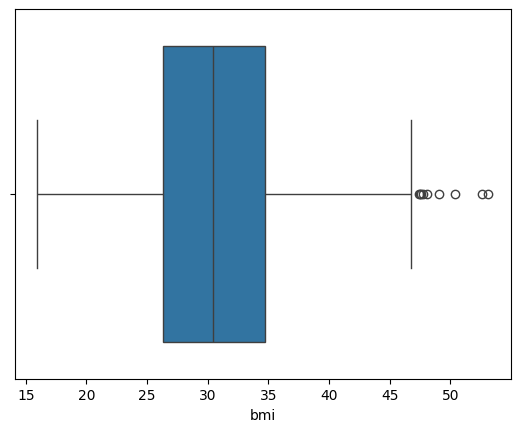

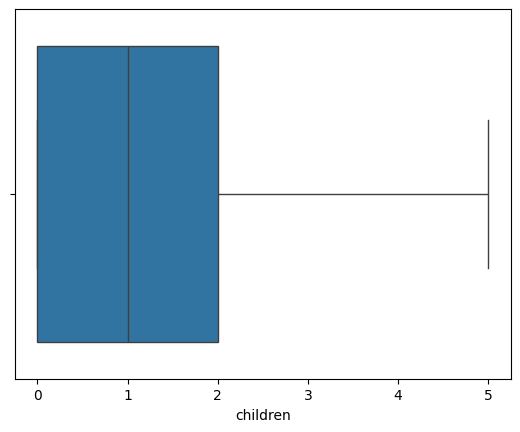

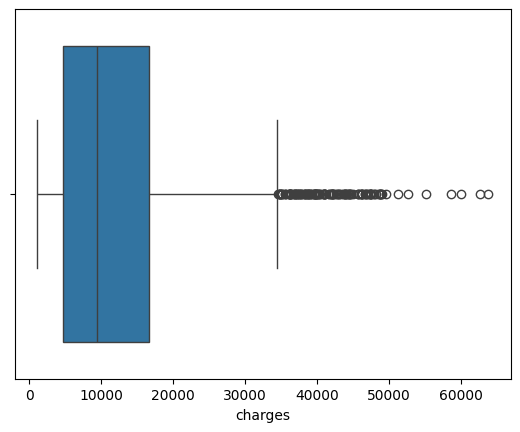

In [15]:
for column in number_column:
    sns.boxplot(data = df , x = column )
    plt.show()

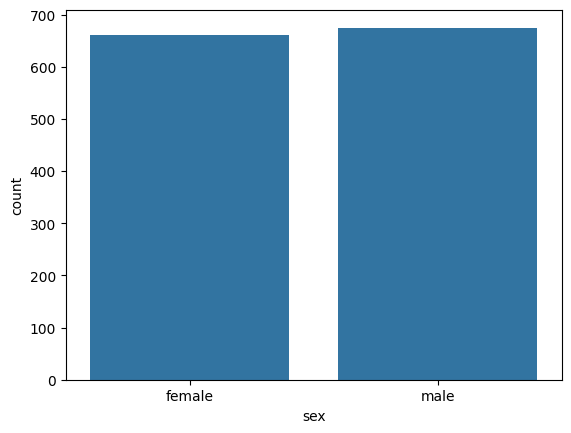

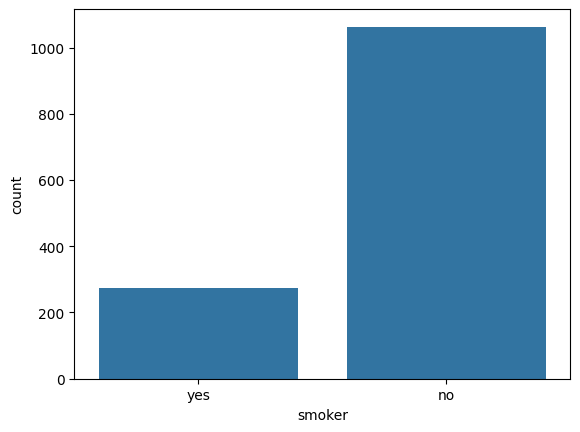

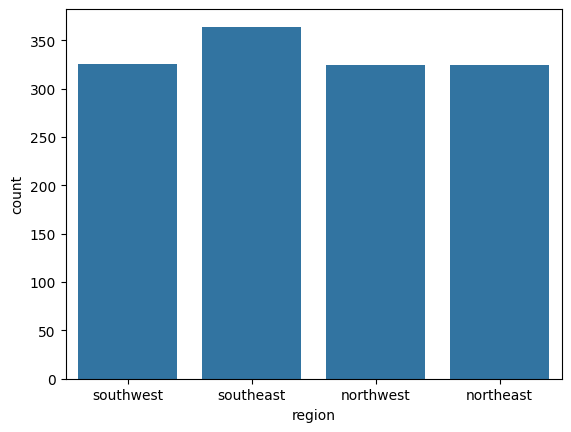

In [16]:
for column in object_column:
    sns.countplot(data = df , x = column )
    plt.show()

In [17]:
pd.crosstab(df['sex'] , df['smoker'])

smoker,no,yes
sex,,
female,547,115
male,516,159


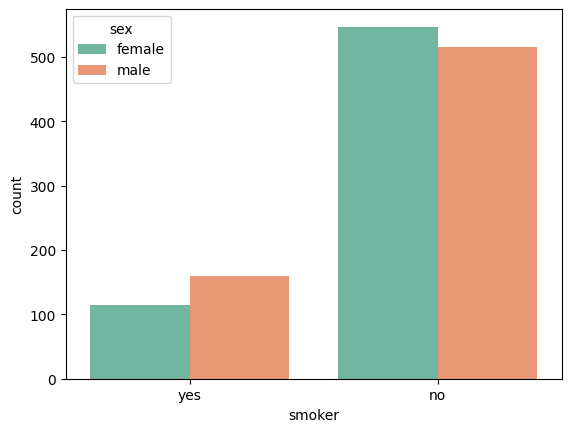

In [18]:
sns.countplot(data =df , x = 'smoker' , hue = 'sex' , palette='Set2')
plt.show()

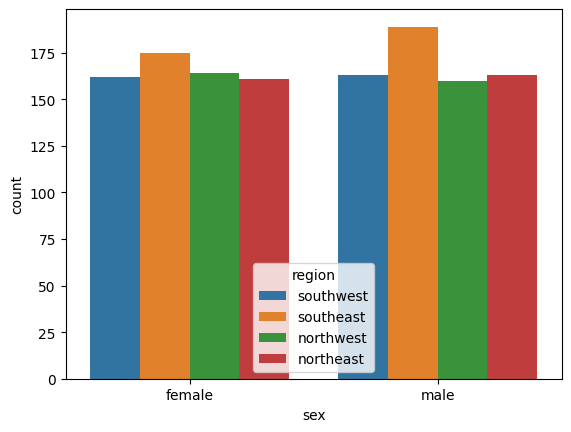

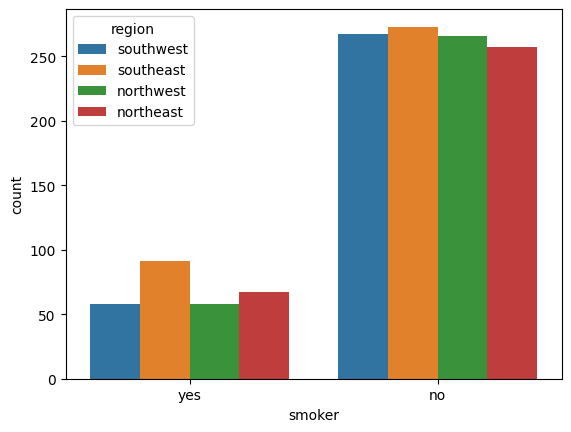

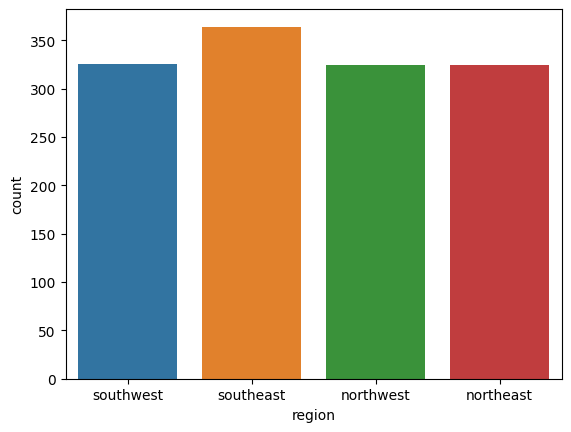

In [19]:
for column in object_column:
    sns.countplot(data = df , x = column  ,hue = 'region')
    plt.show()

## Perceptron: A Simple Neural Network

The Perceptron is one of the simplest types of artificial neural networks. It was introduced by Frank Rosenblatt in 1958 and is designed to solve machine learning tasks.

### How the Perceptron Works:
1. **Inputs and Weights**: Each feature of the dataset is given an associated weight, which represents its importance.
2. **Weighted Sum**: The input features are multiplied by their respective weights and summed up.
3. **Activation Function**: The weighted sum is passed through an activation function (e.g., step function), which outputs a binary value (0 or 1).
4. **Learning**: The weights are adjusted iteratively using the Perceptron Learning Rule to minimize classification errors.

### Perceptron Algorithm:
1. Initialize weights and bias to zero or small random values.
2. For each data point:
   - Calculate the output using the current weights and bias.
   - Update weights and bias based on the error using the formula:
     \[
     w_i = w_i + \Delta w_i \quad \text{where} \quad \Delta w_i = \eta \cdot (y - \hat{y}) \cdot x_i
     \]
     \[
     b = b + \eta \cdot (y - \hat{y})
     \]
   Here:
   - \( w_i \): Weight for feature \( i \)
   - \( \eta \): Learning rate
   - \( y \): Actual label
   - \( \hat{y} \): Predicted label
   - \( x_i \): Feature value
   
3. Repeat the process until the error is minimized or a set number of iterations is reached.

The perceptron is the foundation of modern deep learning models, though it works only for linearly separable data.


### **Classification Task 1: Predicting Gender**

In this task, our goal is to predict the **gender** of individuals based on other features available in the dataset. This involves using the provided attributes as inputs to build a classification model that can determine whether an individual is male or female.

### **Features Used for Prediction**
We will utilize the following features to make predictions about gender:

1. **Age**: The age of the individual.
2. **BMI**: Body Mass Index, a measure of body fat based on height and weight.
3. **Children**: The number of children/dependents the individual has.
4. **Smoker**: Whether the individual is a smoker or not (Yes/No).
5. **Region**: The region of residence (e.g., northeast, northwest, southeast, southwest).
6. **Charges**: The insurance cost charged to the individual.

### **Objective**
The objective is to build a classification model that can accurately predict the gender (male or female) based on the combination of these features. We aim to evaluate the model's performance and understand how each feature contributes to the prediction.




#### Data Preparation for the Model

Before feeding the data into the model, it is essential to perform some preprocessing steps to ensure the data is in a suitable format for training. These steps are crucial for the Perceptron algorithm to converge effectively and provide meaningful results. The key preprocessing steps include:

#### 1. Normalization of Numerical Columns
Normalization is required because:
- **Different scales of features**: The numerical features, such as `age`, `bmi`, and `charges`, may have significantly different ranges. When features are on different scales, the learning algorithm may prioritize certain features over others, leading to biased learning. For example, a large feature like `charges` may dominate the model's learning process if not normalized.
- **Speed of Convergence**: Perceptron and other gradient-based algorithms often perform better when the features are normalized. If one feature dominates due to its scale, the model might converge very slowly or get stuck in a local minimum.
- **Improved Performance**: Normalization ensures that all features contribute equally to the model’s learning process, allowing the algorithm to work more efficiently.

#### 2. One-Hot Encoding of Categorical Columns
One-hot encoding is required because:
- **Non-numeric data**: Machine learning models, including Perceptron, require numerical input. Categorical columns like `smoker` and `region` cannot be directly used by the model as they are non-numeric. One-hot encoding transforms these categorical variables into a series of binary columns, allowing the model to interpret them correctly.
- **Representation of categories**: One-hot encoding ensures that each category is represented as a separate binary feature, avoiding any ordinal or hierarchical assumptions that might be made by algorithms if the categories were represented as integers. For instance, treating the `smoker` feature as integers (1 for "yes", 0 for "no") may suggest an ordering (e.g., "yes" > "no"), which is incorrect in this context.
  
#### 3. Handling Missing or Erroneous Data
Handling missing or erroneous data is required because:
- **Ensuring completeness**: Most machine learning algorithms, including Perceptron, cannot handle missing values. If the dataset has missing values, the model may fail to train or produce unreliable predictions. It is crucial to impute or remove missing data to ensure that the model can process the data correctly.
- **Avoiding bias**: If missing data is ignored or handled improperly, it can introduce bias into the model, making the predictions inaccurate. For instance, simply removing rows with missing values may lead to biased results if the missing data is not missing at random.
  


#### Define the Feature and Target variables

In [20]:
X = df[['age', 'bmi', 'children', 'smoker', 'region', 'charges']]
y = df['sex'].map({'male': 0, 'female': 1})

#### Noralization and One Hot Encoding is handled using Column Transformer here

The Column Transformer is a method in python that helps you apply various functions like StandardScalar() and OneHotEncoding() in the form of a pipeline to any of the columns you want.

In [21]:
numerical_features = list(number_column.columns) # We defined all numerical columns as number_column above in the notebook
numerical_transformer = StandardScaler()

# Categorical columns to one-hot encode
categorical_features = X.select_dtypes(include='object').columns  # We defined all categorical columns as object_column above in the notebook
categorical_transformer = OneHotEncoder(drop='first') # Adds new columns to the dataset

# Combine preprocessors in a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit and transform the entire dataset (excluding the target column, assuming it's 'sex')
X_transformed = preprocessor.fit_transform(X)

# Extract feature names for the transformed DataFrame
numerical_names = numerical_features
categorical_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = list(numerical_names) + list(categorical_names)

df_X_transformed = pd.DataFrame(X_transformed, columns= feature_names)



In [22]:
X_transformed

array([[-1.44041773, -0.45315959, -0.90923416, ...,  0.        ,
         0.        ,  1.        ],
       [-1.51164747,  0.50942165, -0.07944162, ...,  0.        ,
         1.        ,  0.        ],
       [-0.79935006,  0.3831546 ,  1.58014347, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.51164747,  1.01448983, -0.90923416, ...,  0.        ,
         1.        ,  0.        ],
       [-1.29795825, -0.79752426, -0.90923416, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.55123139, -0.26129928, -0.90923416, ...,  1.        ,
         0.        ,  0.        ]])

##### We have finally pre processed the data and it is ready to be fed to the Perceptron model

In [23]:
df_X_transformed

,age,bmi,children,charges,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440418,-0.453160,-0.909234,0.297857,1.0,0.0,0.0,1.0
1,-1.511647,0.509422,-0.079442,-0.954381,0.0,0.0,1.0,0.0
2,-0.799350,0.383155,1.580143,-0.729373,0.0,0.0,1.0,0.0
3,-0.443201,-1.305052,-0.909234,0.719104,0.0,1.0,0.0,0.0
4,-0.514431,-0.292456,-0.909234,-0.777499,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1332,0.767704,0.050269,1.580143,-0.221263,0.0,1.0,0.0,0.0
1333,-1.511647,0.206053,-0.909234,-0.914695,0.0,0.0,0.0,0.0
1334,-1.511647,1.014490,-0.909234,-0.962287,0.0,0.0,1.0,0.0
1335,-1.297958,-0.797524,-0.909234,-0.931054,0.0,0.0,0.0,1.0


In [24]:
y

,sex
0,1
1,0
2,0
3,0
4,0
...,...
1332,0
1333,1
1334,1
1335,1


#### Model Building Using PyTorch

In [25]:
# The Features
X_transformed

array([[-1.44041773, -0.45315959, -0.90923416, ...,  0.        ,
         0.        ,  1.        ],
       [-1.51164747,  0.50942165, -0.07944162, ...,  0.        ,
         1.        ,  0.        ],
       [-0.79935006,  0.3831546 ,  1.58014347, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.51164747,  1.01448983, -0.90923416, ...,  0.        ,
         1.        ,  0.        ],
       [-1.29795825, -0.79752426, -0.90923416, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.55123139, -0.26129928, -0.90923416, ...,  1.        ,
         0.        ,  0.        ]])

In [26]:
# The Target Variable
y = np.array(y)
y

array([1, 0, 0, ..., 1, 1, 1])

In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

In [28]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # Make it 2D for PyTorch
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


In [29]:
class Perceptron(nn.Module):
    def __init__(self, input_size):
        super(Perceptron, self).__init__()
        self.fc = nn.Linear(input_size, 1)  # Fully connected layer with 1 output

    def forward(self, x):
        x = self.fc(x)
        x = torch.sigmoid(x)  # Sigmoid activation for binary classification
        return x

# Initialize the model
input_size = X_train.shape[1]
model = Perceptron(input_size)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training loop
epochs = 100
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.7318
Epoch [20/100], Loss: 0.7295
Epoch [30/100], Loss: 0.7273
Epoch [40/100], Loss: 0.7253
Epoch [50/100], Loss: 0.7233
Epoch [60/100], Loss: 0.7214
Epoch [70/100], Loss: 0.7197
Epoch [80/100], Loss: 0.7180
Epoch [90/100], Loss: 0.7164
Epoch [100/100], Loss: 0.7149


In [30]:
# Evaluation
with torch.no_grad():
    y_pred = model(X_test)
    y_pred_class = (y_pred > 0.5).float()  # Thresholding at 0.5
    accuracy = accuracy_score(y_test, y_pred_class)
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_class))

Accuracy: 0.5448
Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.51      0.51       125
         1.0       0.57      0.57      0.57       143

    accuracy                           0.54       268
   macro avg       0.54      0.54      0.54       268
weighted avg       0.54      0.54      0.54       268

